## Hierarchical clustering analysis of within-scanner SC variability

The interactive version of this notebook is available at [https://github.com/TheAxonLab/hcph-sops/tree/mkdocs/docs/analysis](https://github.com/TheAxonLab/hcph-sops/tree/mkdocs/docs/analysis).

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy.stats as stats

from matplotlib.colors import to_hex
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.cluster import ward_tree
from sklearn.manifold import TSNE
from nireports.reportlets.nuisance import _ward_to_linkage


from confounds import get_confounds
from simulate_sc import simulate_sc_density_bias
from load_save import save_caption, load_matrices, init_save_layout

# Fix the random seed the same way as in the defacing registered report (RR)
day = 231108  # day and time the journal published our HCPh stage 1 RR
time = 105017
random_seed = day + time

# Define paths
code_path = Path("/data/code/hcph-sops/")
dataset_path = Path("/data/datasets/hcph-dataset")
suppl_path = Path("/data/derivatives/hcph-suppl/")
confound_path = Path("/data/datasets/hcph-dataset/phenotype/mood_env_quest.tsv")
iqms_path = Path("/data/derivatives/hcph-mriqc/group_dwi.tsv")

#Define filtering parameters
# TO DO: adapt the filtering parameters to load the SC instead of the FC
fc_path = Path(f"/data/derivatives/hcph-fc/")
metric = "correlation"
atlas_dimension = 64
fd_threshold = 0.5
fdthresh_str = str(fd_threshold).replace(".", "")

## Simulate SC matrices with a set bias

We will use simulated SC matrices with an artifical set bias in the within-scanner variability to develop a Bland-Altman and hierarchical analyses capable of detecting such biases. Once the methodology is refined, we will apply it on the real HCPh data.

In [2]:
atlas_dim = 64
connectome_atlas_as_ref = False
num_sessions = 36
SC_matrices, noise = simulate_sc_density_bias(atlas_dim=atlas_dim, connectome_atlas_as_ref=connectome_atlas_as_ref, num_sessions = num_sessions)

Simulating a reference SC matrix using a log-normal distribution.
Simulated a series of 36 SC matrices of shape (64x64) with higher variability (std=0.5) in lower density connections.


### Prepare the SC matrices array for input in hierarchical clustering

To prepare the SC matrices array to input it in a hierarchical clustering analysis, we will keep only the lower triangle of each SC matrix and unravel it into a row vector.

In [3]:
# Extract the lower triangle of each SC matrix and unravel it into a row vector
SC_matrices_tril = np.array(
    [SC_matrices[i][np.tril_indices(atlas_dim, k=-1)] for i in range(num_sessions)]
)

print(f"Shape of the concatenated flattened lower triangle SC matrices array: {SC_matrices_tril.shape}")
# Test whether the shape is as expected
assert SC_matrices_tril.shape == (num_sessions, atlas_dim * (atlas_dim - 1) // 2)

Shape of the concatenated flattened lower triangle SC matrices array: (36, 2016)


## Load SC matrices
For now I don't have the SC matrices, so I will run the code on the FC matrices for testing and curiosity

[get_dataset_dir] Dataset found in /home/cprovins/nilearn_data/difumo_atlases
Configuration 'hcph' already exists, skipping add_config_paths.
Number of brain regions (matrix size): 62
Shape of concatenated upper triangle FC matrices (number of region pairs, number of sessions): (36, 1953)


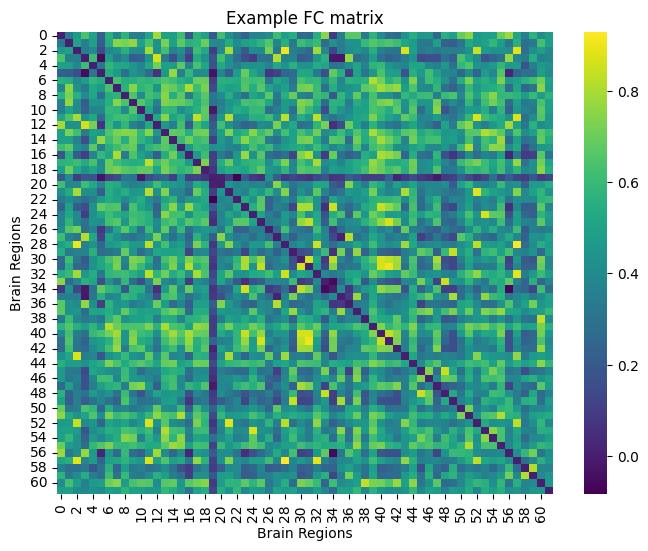

In [4]:
# Set up entities_base for the matrix loading
entities_base = {
    'subject': '001',
    'task': 'rsmovie',
    'measure': metric,
    'scale': str(atlas_dimension),
    'fd_threshold': fdthresh_str,
}

# Load the FC matrices and associated information using the helper function
matrices_dict = load_matrices(fc_path, entities_base, code_path)
fc_concat = matrices_dict["conn_concat"]
files = matrices_dict["files"]
region_labels = matrices_dict["region_labels"]
fc_size = matrices_dict["conn_size"]
ses_index = matrices_dict["ses_index"]

# Intialize the BIDSLayout to save the figures and their associated captions      
save_layout = init_save_layout(code_path, suppl_path)

# Plot an example FC matrix (the last one loaded)
fc_matrix = np.zeros((fc_size, fc_size))
# reconstruct from upper triangle if needed (optional, for visualization)
fc_matrix[np.triu_indices(fc_size, k=0)] = fc_concat[-1].flatten()
fc_matrix += np.triu(fc_matrix, k=1).T
plt.figure(figsize=(8,6))
sns.heatmap(fc_matrix, cmap='viridis')
plt.title(f"Example FC matrix")
plt.xlabel('Brain Regions')
plt.ylabel('Brain Regions')

print(f"Number of brain regions (matrix size): {fc_size}")
print(f"Shape of concatenated upper triangle FC matrices (number of region pairs, number of sessions): {fc_concat.shape}")

# Test whether the shape is as expected
assert fc_concat.shape == (36, fc_size * (fc_size + 1) // 2)

SC_matrices_tril = fc_concat

## Perform hierarchical clustering to identify what sessions are more similar

In [5]:
# Add the information that apply too all figures generated below to the base entities
entities_base["experiment"] = "clusteringfc"
entities_base["extension"] = ".svg"
entities_base["datatype"] = "figures"
entities_base["suffix"] = "bold"

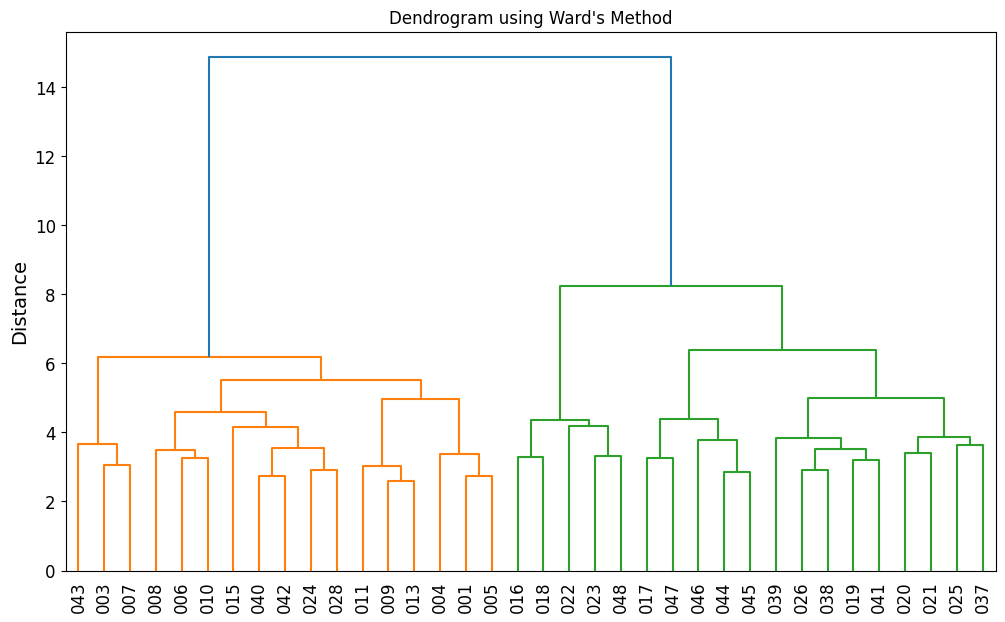

In [6]:
# Perform hierarchical clustering using Ward's method
# linkage_matrix_scipy = linkage(SC_matrices_tril, method="ward") # dendrogram(linkage_matrix) # we pre-registered that we would use scikit-learn

children, _, n_leaves, _, distances = ward_tree(SC_matrices_tril, return_distance=True)
linkage_matrix = _ward_to_linkage(children, n_leaves, distances)

# Generate and plot the dendrogram with actual session indices as x-tick labels
plt.figure(figsize=(12, 7))
dendrogram(linkage_matrix, labels=ses_index)
plt.title("Dendrogram using Ward's Method")
plt.ylabel("Distance", fontsize=14)
plt.xticks(fontsize=12, rotation=90)
plt.yticks(fontsize=12)
plt.show()

## Perform clustering using t-distributed Stochastic Neighbor Embedding (t-SNE)

In [7]:
# Perform t-SNE to reduce dimensions to 2D
tsne = TSNE(n_components=2, random_state=random_seed)
tsne_embedding = tsne.fit_transform(SC_matrices_tril)

# TO DO: the documentation of t-SNE mention
# It is highly recommended to use another dimensionality reduction method (e.g. PCA for dense data or TruncatedSVD for sparse data)
# to reduce the number of dimensions to a reasonable amount (e.g. 50) if the number of features is very high.

## What factor has an influence on the sessions similarity?

We will retrieve a serie of confound factors for each session to investigate whether they influenced how similar sessions are; in other words whether they can explain a higher or lower variability across session. Specifically, we are interested in the time of day, the average head-motion summarized by framewise displacement (FD), room temperature at start and PE direction.

In [8]:
confounds_of_interest = ['mr_room_temperature', 'caffeine_2h', 'caffeine_24h']
iqms_of_interest = ['fd_mean']
scans_df = get_confounds(dataset_path, confound_path, confounds_of_interest, iqms_path=iqms_path, iqms_of_interest=iqms_of_interest)

"""
# Keep only dMRI scans
scans_df = scans_df[scans_df["modality"] == "dwi"]
scans_df.drop(columns=["task"], inplace=True)

# There are two runs of DWI in session 011, which expand into 2 pairs of identical rows in scans_df. From the scanning notes it is not clear why has it does not report an issue during acquisition. Let us keep only the values associated with the 2nd run (only fd_mean differ between those 4 rows)
scans_df = scans_df.drop([328, 329, 330])
"""
# %%%%%%
# TO DO: delete this part of the code that is for FMRI 
# Keep only the magnitude part of functional scans, first echo and rsmovie task
iqms_path = Path("/data/derivatives/hcph-mriqc/group_bold.tsv")
scans_df = get_confounds(dataset_path, confound_path, confounds_of_interest, iqms_path=iqms_path, iqms_of_interest=iqms_of_interest)
scans_df = scans_df[scans_df["modality"] == "func"]
scans_df = scans_df[scans_df["task"] == "rsmovie"]
# %%%%%%

# Keep only the reliability sessions
scans_df = scans_df[scans_df["session"].str.startswith("0")]

# Verify that the confunds have been defined for all dwi scans
assert scans_df["fd_mean"].notna().all(), "There are NaN values in fd_mean column"
assert scans_df["time_of_day"].notna().all(), "There are NaN values in time column"
assert scans_df["pe_dir"].notna().all(), "There are NaN values in pe_dir column"
assert scans_df["mr_room_temperature"].notna().all(), "There are NaN values in mr_room_temperature column"

# Create dataframe based on the list of files
files_df = pd.DataFrame(files, columns=['file_path'])
files_df = files_df.assign(
    subject=files_df["file_path"].str.extract(r"sub-(\d+)/"),
    session=files_df["file_path"].str.extract(r"ses-(\w+)/"),
)

#Pair filenames with acquisition time
confounds_df = pd.merge(
        scans_df, files_df, on=["subject", "session"], how="inner"
    )
confounds_df.drop(columns=["file_path"], inplace=True)

assert confounds_df.shape[0] == 36, f"The number of confound rows {confounds_df.shape[0]} does not match the 36 expected sessions."
confounds_df.head()

,filename,acq_time,subject,session,modality,task,pe_dir,day_of_week,time_of_day,fd_mean,mr_room_temperature,caffeine_2h,caffeine_24h
0,sub-001/ses-001/func/sub-001_ses-001_task-rsmo...,2023-10-20T19:50:01.187500,001,001,func,rsmovie,LR,Friday,20:00:00,0.119245,19.4,0.0,2.0
1,sub-001/ses-003/func/sub-001_ses-003_task-rsmo...,2023-10-21T10:12:32.207500,001,003,func,rsmovie,LR,Saturday,10:00:00,0.096035,18.9,1.0,1.0
2,sub-001/ses-004/func/sub-001_ses-004_task-rsmo...,2023-10-21T12:22:08.222500,001,004,func,rsmovie,RL,Saturday,12:00:00,0.146882,18.9,0.0,1.0
3,sub-001/ses-005/func/sub-001_ses-005_task-rsmo...,2023-10-22T10:33:53.380000,001,005,func,rsmovie,PA,Sunday,11:00:00,0.112293,18.8,1.0,1.0
4,sub-001/ses-006/func/sub-001_ses-006_task-rsmo...,2023-10-22T12:18:06.200000,001,006,func,rsmovie,PA,Sunday,12:00:00,0.088701,19.0,1.0,1.0


In [9]:
# Helper function to plot a dendrogram with a color strip under leaf labels according to a confound/factor,
# and a tSNE plot on the right, coloring points by the same factor.
def plot_dendrogram_and_tsne_colored_with_factor(
    linkage_matrix, 
    ses_index, 
    confounds_df, 
    SC_matrices_2d,          # tSNE coordinates, shape (n_sessions, 2)
    factor_col="pe_dir", 
    palette="colorblind", 
    legend_title="Phase Encoding Direction",
    xlabel="Session Index",
    entities = None
):
    """
    Plot a dendrogram with a color strip under leaf labels according to a confound/factor,
    and a tSNE plot colored by the same factor.

    Args:
        linkage_matrix: linkage matrix for the dendrogram
        ses_index: list of row/session indices, matches input data order
        confounds_df: DataFrame containing factor_col and ses_index-matching rows
        SC_matrices_2d: Array with tSNE coordinates (n_sessions, 2)
        factor_col: column of confounds_df to color leaves/strip and tSNE by
        palette_name: seaborn palette name for categorical hues
        legend_title: title for legend
        xlabel: x-axis label for dendrogram
        entities: entities to save the plot (optional)
    """
    import matplotlib.patches as mpatches

    # Get color mapping for unique values of the factor
    if factor_col == "mr_room_temperature":
        # Sort the temperature values so color goes from low to high
        factor_values = np.sort(confounds_df[factor_col].unique())
        if type(palette) is str:
            palette = sns.color_palette(palette, len(factor_values))
        value_to_color = {val: to_hex(color) for val, color in zip(factor_values, palette)}

    elif factor_col == "fd_mean":
        # For fd_mean, bin into 0.01 increments, then color by bin (ascending)
        binned_fd = np.floor(confounds_df[factor_col] / 0.01) * 0.01
        factor_values = np.sort(np.unique(binned_fd))
        if type(palette) is str:
            palette = sns.color_palette(palette, len(factor_values))
        value_to_color = {val: to_hex(color) for val, color in zip(factor_values, palette)}

    elif factor_col == "time_of_day":
        # Known values are "10:00", "11:00", "12:00", "22:00" etc.
        factor_values = np.unique(confounds_df[factor_col])
        # Morning: <= 12:00, Evening: > 12:00
        warm_vals = [val for val in factor_values if val.hour <= 12]
        cold_vals = [val for val in factor_values if val.hour > 12]

        palette_warm = sns.color_palette("YlOrRd", max(len(warm_vals), 1))
        palette_cold = sns.color_palette("Blues", max(len(cold_vals), 1))
        value_to_color = {}
        for val, color in zip(sorted(warm_vals, key=lambda v: v.hour), palette_warm):
            value_to_color[val] = to_hex(color)
        for val, color in zip(sorted(cold_vals, key=lambda v: v.hour), palette_cold):
            value_to_color[val] = to_hex(color)
       
    else:
        factor_values = confounds_df[factor_col].unique()
        if type(palette) is str:
            palette = sns.color_palette(palette, len(factor_values))
        value_to_color = {val: to_hex(color) for val, color in zip(factor_values, palette)}

    def black_link_color_func(cluster_idx):
        return 'black'

    # Set up 2-subplot figure: left dendrogram, right tSNE
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={"width_ratios": [1.8, 1]})

    # --- Dendrogram (left) ---
    ddata = dendrogram(
        linkage_matrix,
        ax=ax1,
        labels=ses_index,
        link_color_func=black_link_color_func,
    )

    # Map from session index to factor value
    if factor_col == "fd_mean":
        # For fd_mean, assign session indices to their binned fd_mean for consistent color mapping
        binned_fd = np.floor(confounds_df[factor_col].values / 0.01) * 0.01
        idx_to_factor = dict(zip(map(str, ses_index), binned_fd))
    else:
        idx_to_factor = dict(zip(map(str, ses_index), confounds_df[factor_col]))

    label_to_color = {idx: value_to_color[idx_to_factor[idx]] for idx in map(str, ses_index)}

    # Color leaf x-axis labels by factor value
    for label in ax1.get_xticklabels():
        idx = label.get_text()
        label.set_color(label_to_color.get(idx, "black"))
        label.set_fontweight('bold')
        label.set_fontsize(14)
        label.set_rotation(90)

    # Draw contiguous color strip under dendrogram leaves
    leaf_order = ddata['ivl']
    strip_colors = [label_to_color[idx] for idx in leaf_order]
    xticks = ax1.get_xticks()
    ymin, ymax = ax1.get_ylim()
    strip_y = ymin - 0.07 * (ymax - ymin)
    strip_height = 0.07 * (ymax - ymin)
    if len(xticks) > 1:
        box_width = xticks[1] - xticks[0]
    else:
        box_width = 1.0
    for x, color in zip(xticks, strip_colors):
        ax1.add_patch(mpatches.Rectangle(
            (x - box_width/2, strip_y), box_width, strip_height, color=color, ec=None, clip_on=False
        ))
    ax1.set_ylim(-1.05, ymax)

    # Show legend for factor values (both axes)
    handles = [mpatches.Patch(color=value_to_color[val], label=str(val)) for val in factor_values]
    ax1.legend(
        handles=handles, 
        title=legend_title, 
        loc="upper right", 
        bbox_to_anchor=(0.98, 1), 
        fontsize=14,
        title_fontsize=14
    )
    ax1.set_ylabel("Distance", fontsize=16)
    ax1.set_xlabel(xlabel, fontsize=16, labelpad=20)
    ax1.tick_params(axis='y', labelsize=14)
    
    # --- t-SNE scatter plot (right) ---
    # Points are colored by the same factor and in the same order as confounds_df/SC_matrices_2d

    # Factor for t-SNE points, must align with SC_matrices_2d order and confounds_df
    if factor_col == "fd_mean":
        # Bin fd_mean values same as we did for coloring dendrogram leaves
        binned_fd = np.floor(confounds_df[factor_col].values / 0.01) * 0.01
        colors_per_point = [value_to_color[binned] for binned in binned_fd]
    else:
        binned_fd = confounds_df[factor_col].values
        colors_per_point = [value_to_color[v] for v in binned_fd]

    ax2.scatter(
        SC_matrices_2d[:, 0], 
        SC_matrices_2d[:, 1], 
        c=colors_per_point,
        s=100
    )

    # Optionally label the points with the session index (if space permits)
    # for i, txt in enumerate(confounds_df["session"]):
    #     ax2.annotate(txt, (SC_matrices_2d[i, 0], SC_matrices_2d[i, 1]), fontsize=9)

    ax2.set_xlabel("t-SNE Dimension 1", fontsize=15, labelpad=15)
    ax2.set_ylabel("t-SNE Dimension 2", fontsize=15, labelpad=10)
    ax2.tick_params(axis='both', labelsize=13)
    #ax2.legend(handles=handles, title=legend_title, loc="best", fontsize=12)
    plt.subplots_adjust(left=0.8)
    plt.tight_layout()

    # Save the figure
    if entities is not None:
        save_path = save_layout.build_path(entities, validate=False)
        plt.savefig(save_path)

    plt.show()

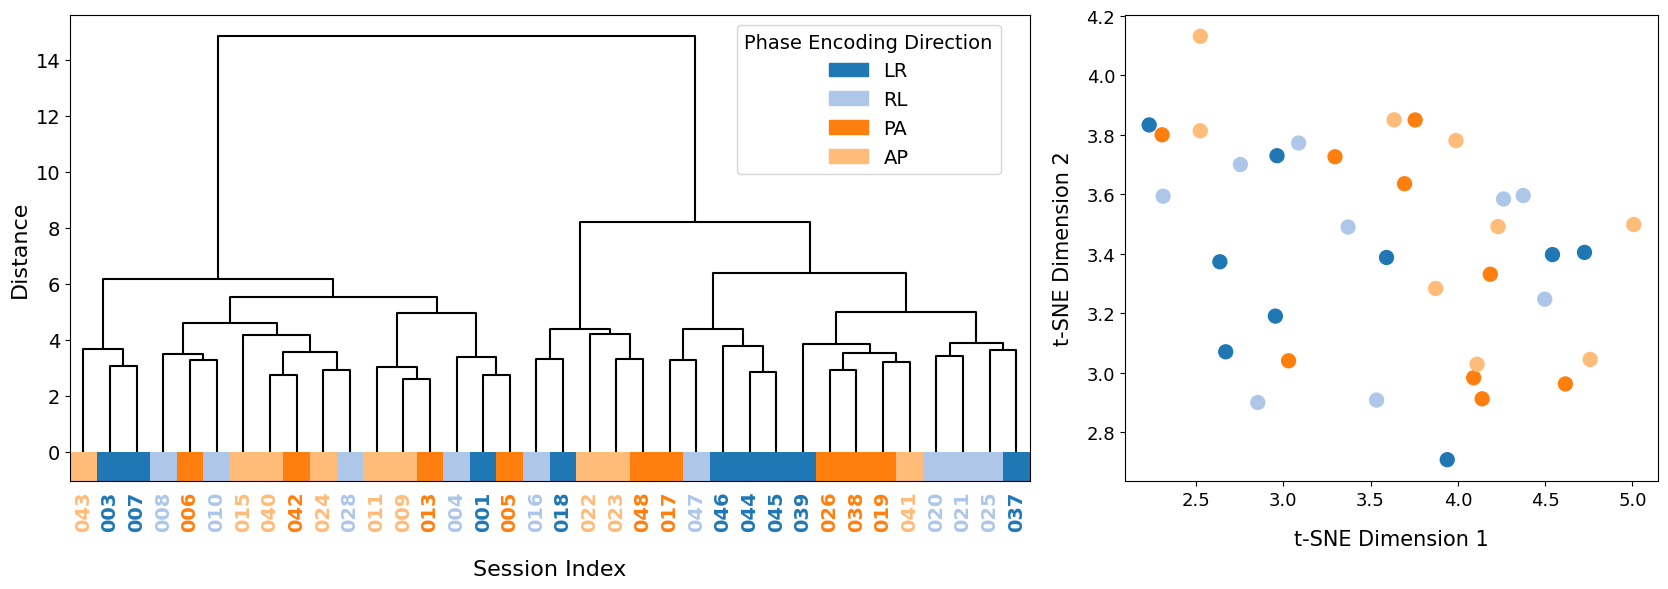

In [10]:
# Entities specific to this plot
entities = {'visualization': 'resdendrogramtsne', 'confound': 'pe_dir'}
entities.update(entities_base)

plot_dendrogram_and_tsne_colored_with_factor(
    linkage_matrix,
    ses_index,
    confounds_df,
    tsne_embedding,
    factor_col="pe_dir",
    palette="tab20",
    legend_title="Phase Encoding Direction",
    xlabel="Session Index",
    entities=entities
)

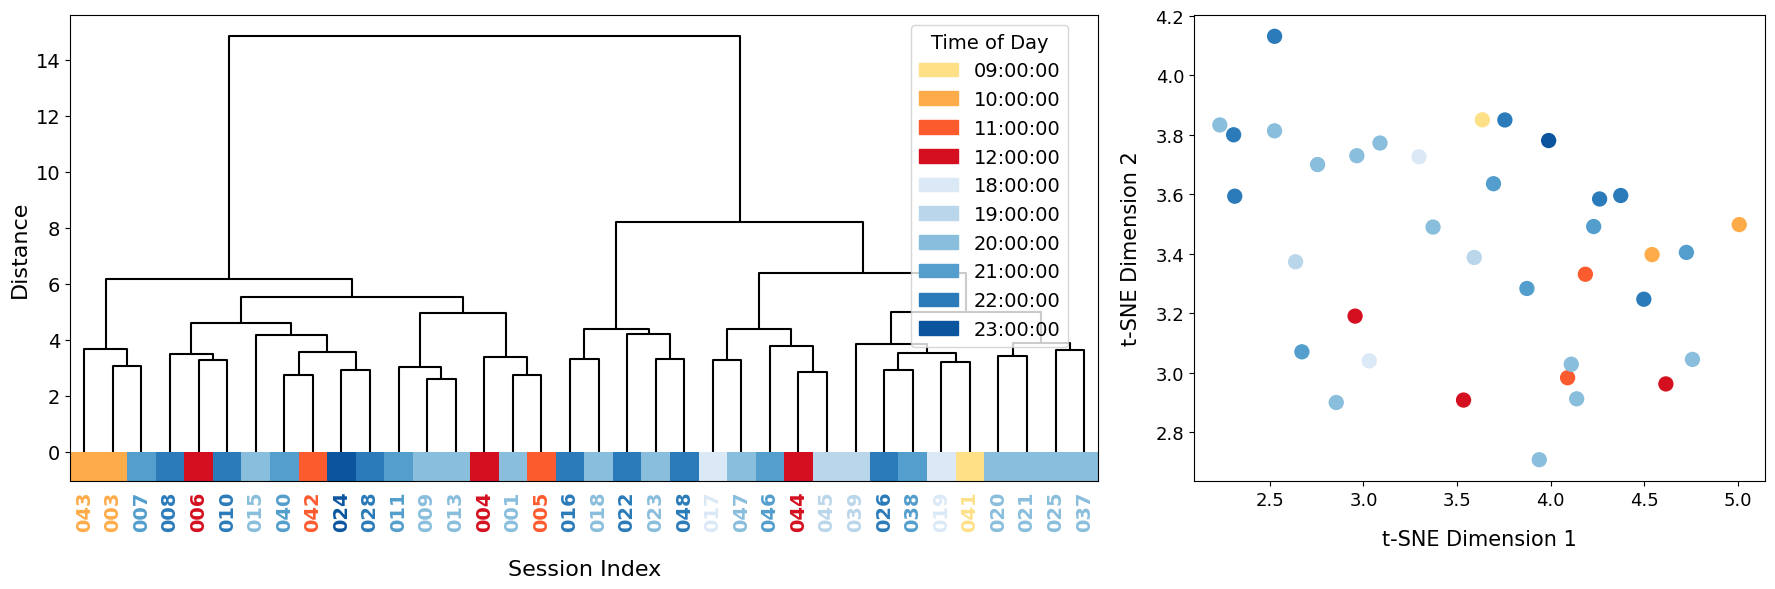

In [11]:
# Entities specific to this plot
entities = {'visualization': 'resdendrogramtsne', 'confound': 'time'}
entities.update(entities_base)

plot_dendrogram_and_tsne_colored_with_factor(
    linkage_matrix,
    ses_index,
    confounds_df,
    tsne_embedding,
    factor_col="time_of_day",
    palette="colorblind",
    legend_title="Time of Day",
    xlabel="Session Index",
    entities=entities
)

If focus only on the evening datapoints, it does look like t SNE puts draws a light separation between darker and lighter points.

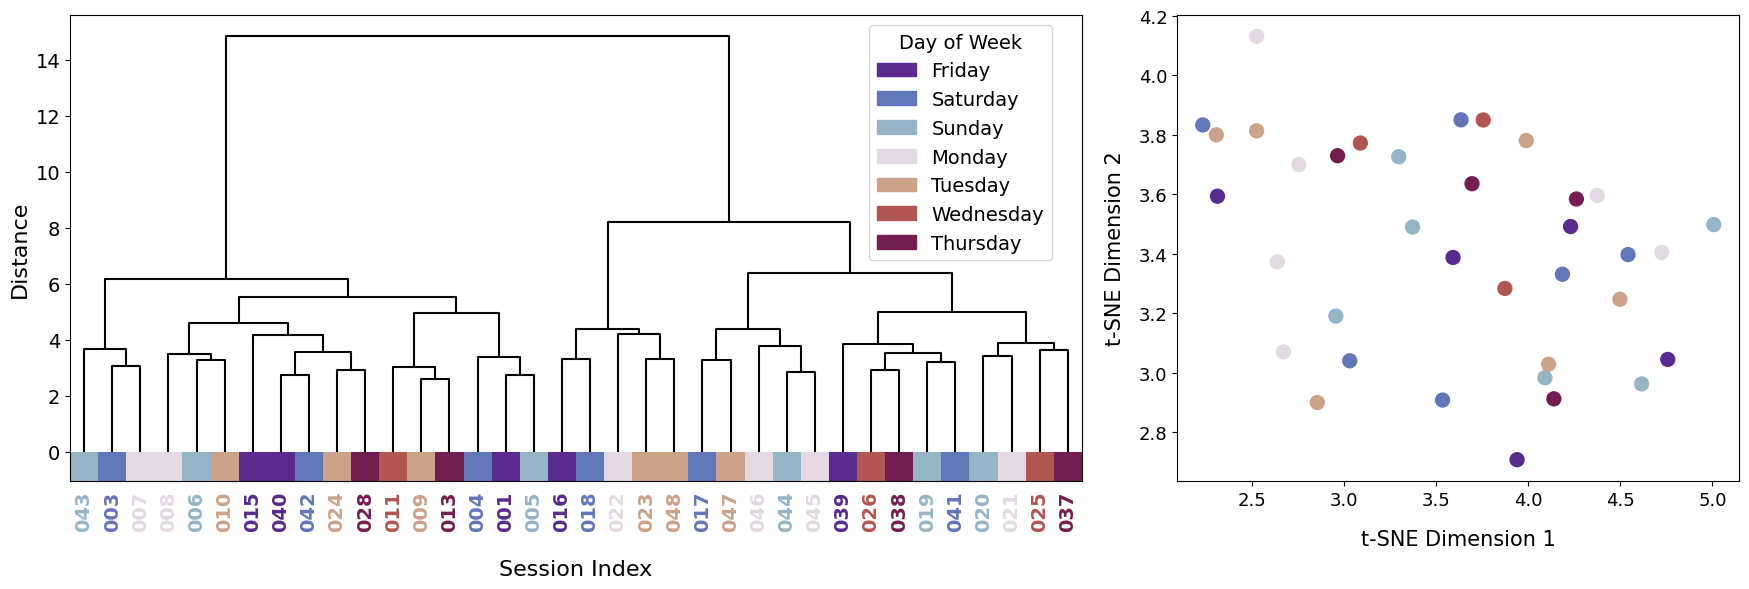

In [12]:
# Entities specific to this plot
entities = {'visualization': 'resdendrogramtsne', 'confound': 'day'}
entities.update(entities_base)

plot_dendrogram_and_tsne_colored_with_factor(
    linkage_matrix,
    ses_index,
    confounds_df,
    tsne_embedding,
    factor_col="day_of_week",
    palette="twilight_shifted",
    legend_title="Day of Week",
    xlabel="Session Index",
    entities=entities
)

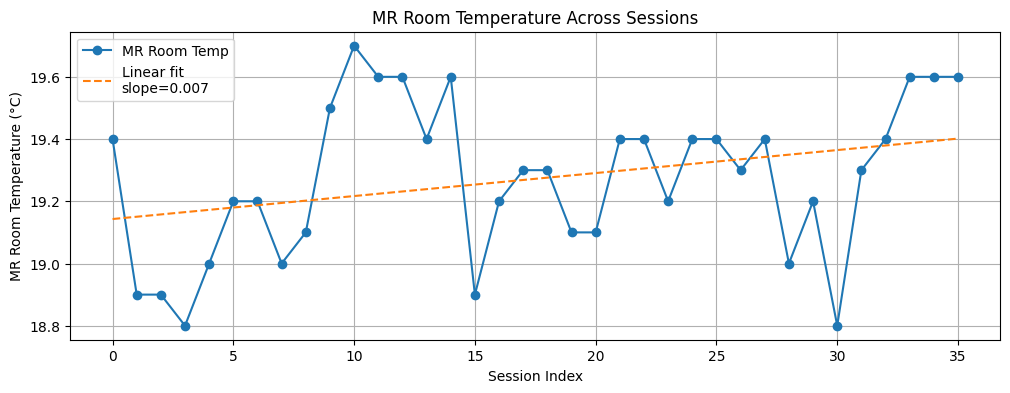

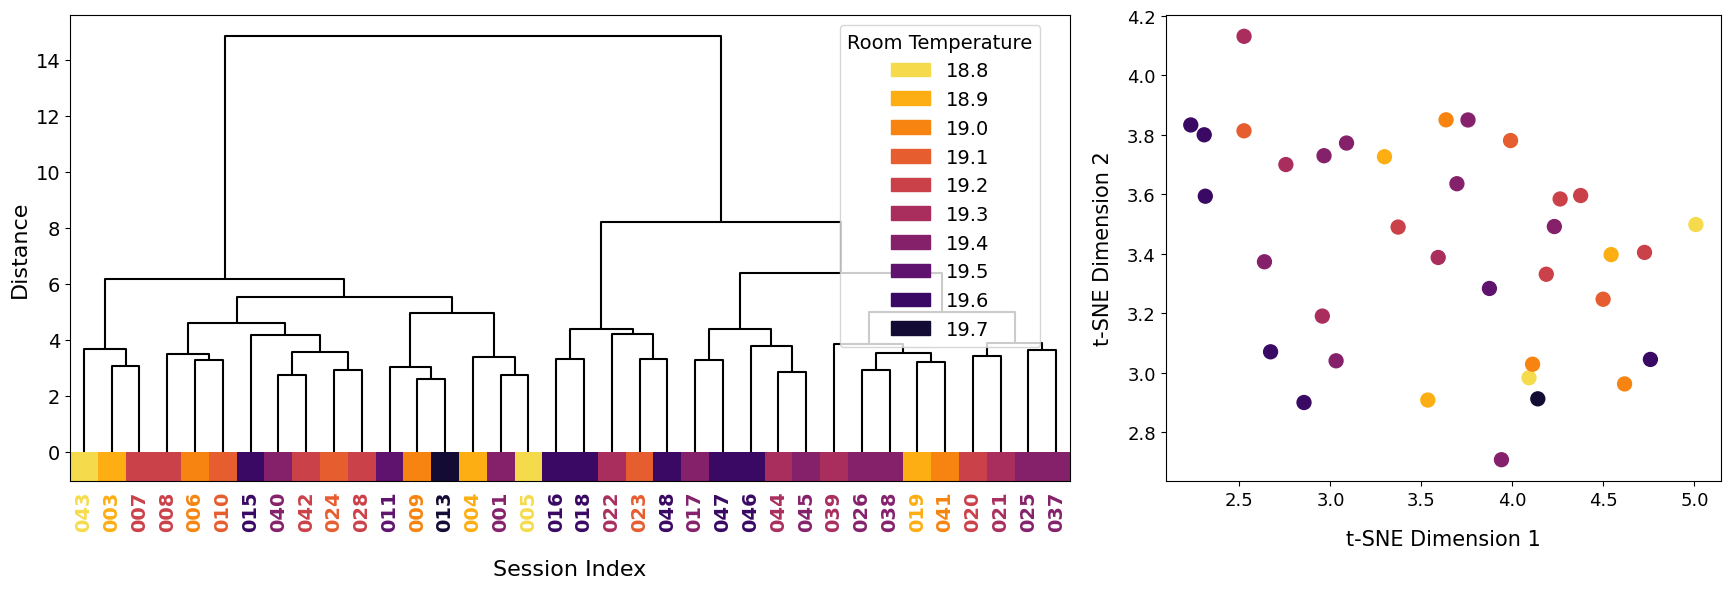

In [13]:
# Entities specific to this plot
entities = {'visualization': 'confevolv', 'confound': 'roomtemp'}
entities.update(entities_base)

room_temp = confounds_df["mr_room_temperature"].values
session_idx = np.arange(len(room_temp))

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(session_idx, room_temp)

plt.figure(figsize=(12, 4))
plt.plot(session_idx, room_temp, marker='o', label="MR Room Temp")
plt.plot(session_idx, intercept + slope * session_idx, '--', 
         label=f"Linear fit\nslope={slope:.3f}")
plt.title("MR Room Temperature Across Sessions")
plt.xlabel("Session Index")
plt.ylabel("MR Room Temperature (°C)")
plt.grid(True)
plt.legend()
#Save the plot
save_path = save_layout.build_path(entities, validate=False)
plt.savefig(save_path)
plt.show()

# Entities specific to this plot
entities = {'visualization': 'resdendrogramtsne', 'confound': 'roomtemp'}
entities.update(entities_base)
plot_dendrogram_and_tsne_colored_with_factor(
    linkage_matrix,
    ses_index,
    confounds_df,
    tsne_embedding,
    factor_col="mr_room_temperature",
    palette="inferno_r",
    legend_title="Room Temperature",
    xlabel="Session Index",
    entities=entities,
)

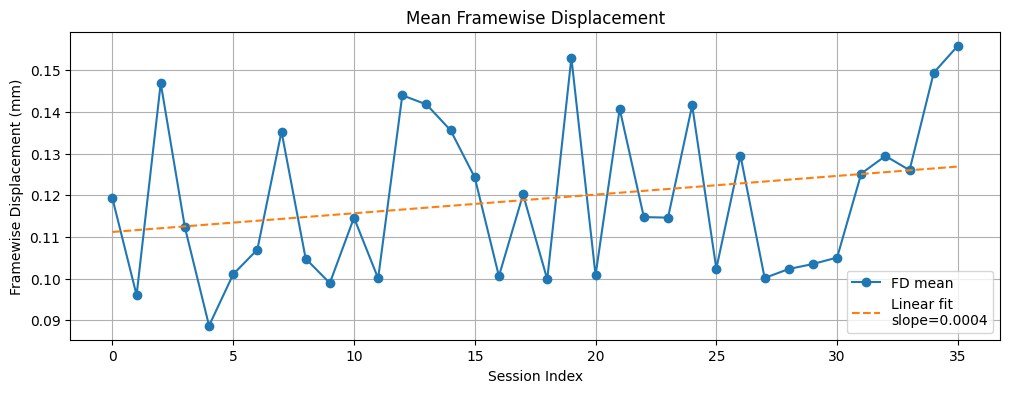

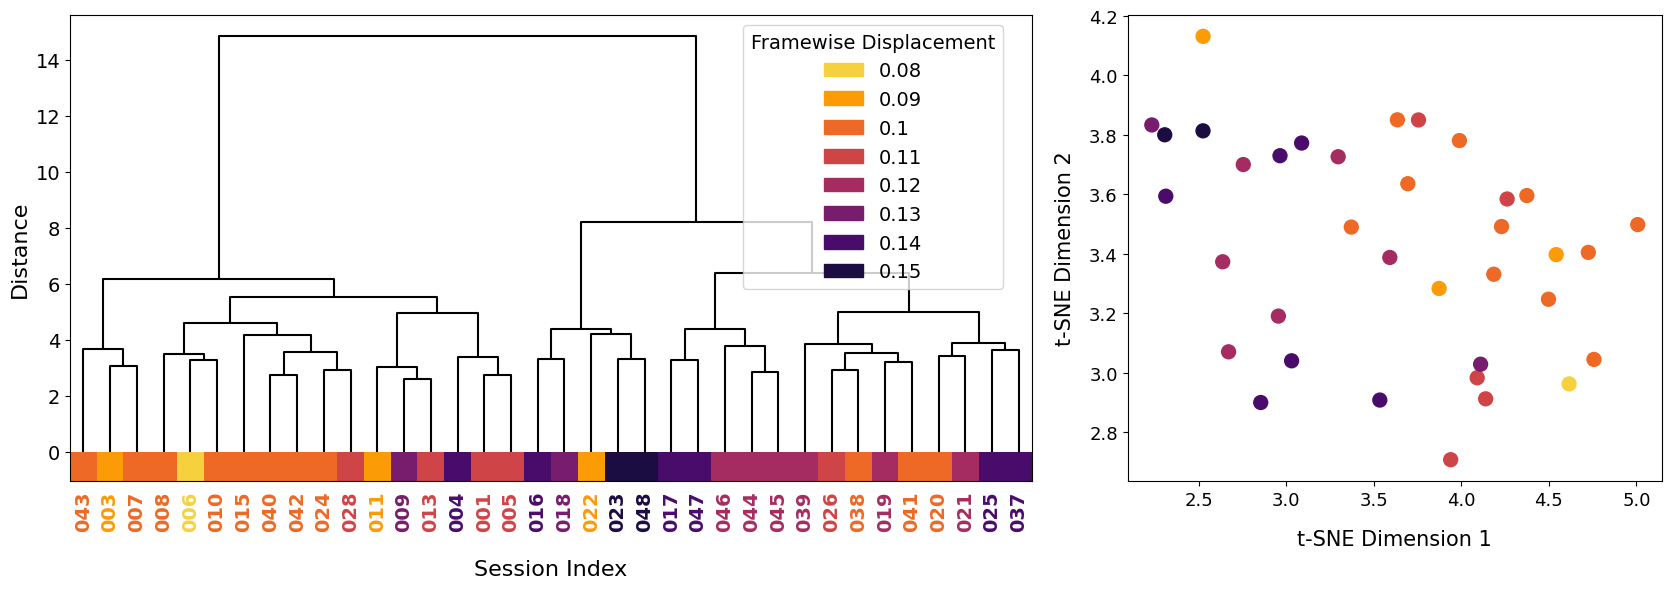

In [14]:
# Entities specific to this plot
entities = {'visualization': 'confevolv', 'confound': 'fd'}
entities.update(entities_base)

fd_mean = confounds_df["fd_mean"].values
session_idx = np.arange(len(fd_mean))

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(session_idx, fd_mean)

plt.figure(figsize=(12, 4))
plt.plot(session_idx, fd_mean, marker='o', label="FD mean")
plt.plot(session_idx, intercept + slope * session_idx, '--', label=f"Linear fit\nslope={slope:.4f}")
plt.title("Mean Framewise Displacement")
plt.xlabel("Session Index")
plt.ylabel("Framewise Displacement (mm)")
plt.grid(True)
plt.legend()
save_path = save_layout.build_path(entities, validate=False)
plt.savefig(save_path)
plt.show()

# Entities specific to this plot
entities = {'visualization': 'resdendrogramtsne', 'confound': 'fd'}
entities.update(entities_base)
plot_dendrogram_and_tsne_colored_with_factor(
    linkage_matrix,
    ses_index,
    confounds_df,
    tsne_embedding,
    factor_col="fd_mean",
    palette="inferno_r",
    legend_title="Framewise Displacement",
    xlabel="Session Index",
    entities=entities
)

It does look FD mean is a driver of session similarity which in accordance with previous litterature (study that showed that higher FD lead to higher reliability)

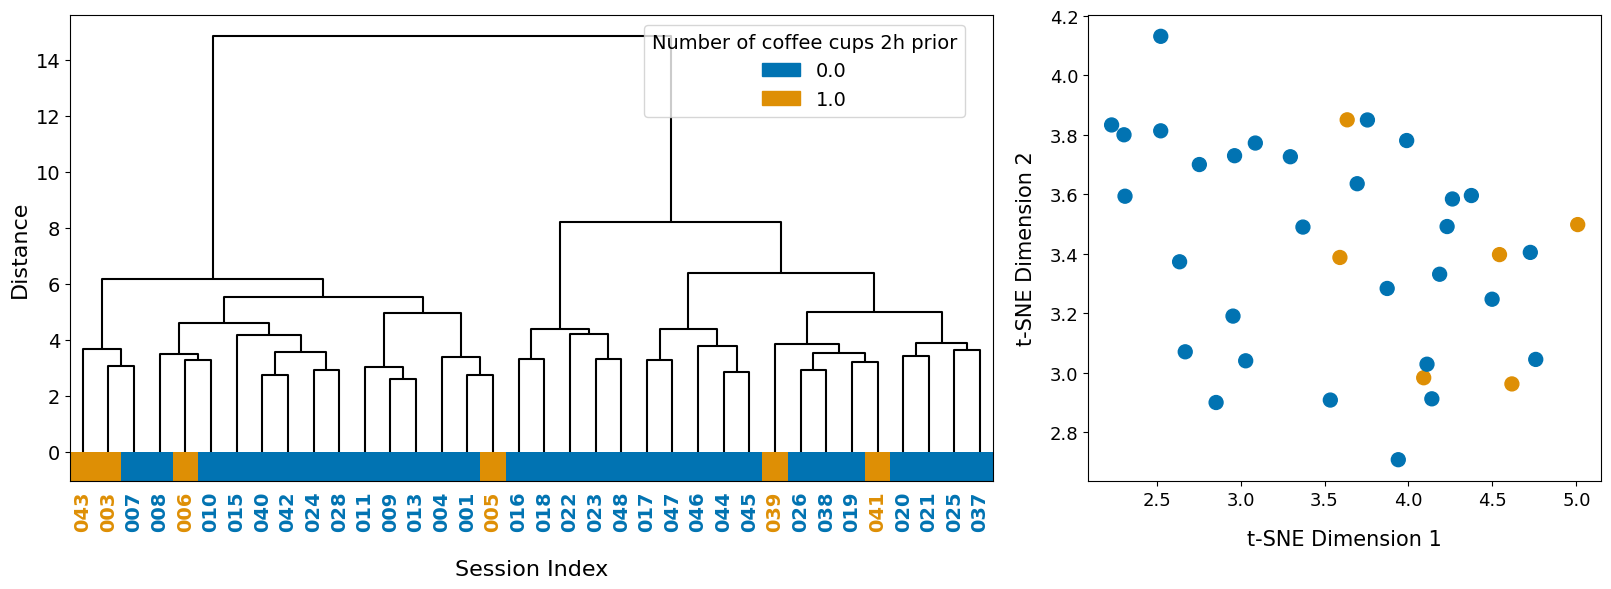

In [15]:
# Entities specific to this plot
entities = {'visualization': 'confevolv', 'confound': 'coffee2h'}
entities.update(entities_base)

plot_dendrogram_and_tsne_colored_with_factor(
    linkage_matrix,
    ses_index,
    confounds_df,
    tsne_embedding,
    factor_col="caffeine_2h",
    palette="colorblind",
    legend_title="Number of coffee cups 2h prior",
    xlabel="Session Index",
    entities=entities
)

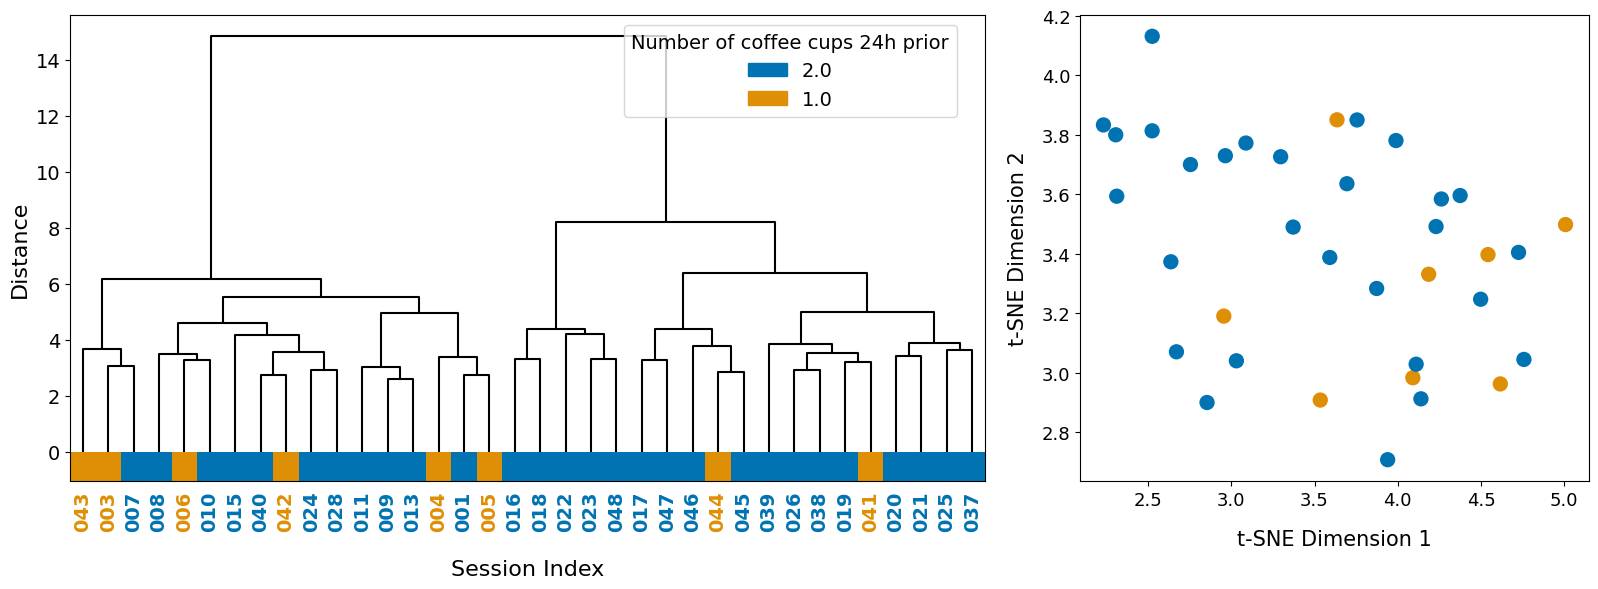

In [16]:
# Entities specific to this plot
entities = {'visualization': 'confevolv', 'confound': 'coffee24h'}
entities.update(entities_base)
plot_dendrogram_and_tsne_colored_with_factor(
    linkage_matrix,
    ses_index,
    confounds_df,
    tsne_embedding,
    factor_col="caffeine_24h",
    palette="colorblind",
    legend_title="Number of coffee cups 24h prior",
    xlabel="Session Index",
    entities=entities
)